<a href="https://colab.research.google.com/github/alfarisauliarahman/BigData26_A_2411533006_AlfarisAuliaRahman/blob/main/Praktikum03/BD_A_T03_2411533006_AlfarisAuliaRahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum Big Data 3

**Nama:** Alfaris Aulia Rahman  
**NIM:** 2411533006  
**Kelas:** A  
**Notebook:** BD_A_T03_2411533006_AlfarisAuliaRahman.ipynb

Notebook mandiri ini menjawab R-1 sampai R-6 pada Modul Praktikum Big Data 03. Jalankan semua sel secara berurutan. P03 dan kode tutorial K tidak diubah. Implementasi tugas memperluas pipeline untuk Januari dan Juli 2023, menambahkan hari libur publik New York, membuat laporan kualitas, kamus seluruh kolom, lineage, serta pemeriksaan hasil tersimpan dan idempotensi.

Di Colab, hasil tersimpan ke `MyDrive/BigData/Praktikum3/Tugas03/`. Saat dijalankan lokal, hasil tersimpan ke `hasil_T03/` pada direktori kerja. Data mentah tidak ditimpa.

Laporan PDF dikerjakan terpisah nanti; notebook ini hanya memuat tugas R-1–R-6 dan artefak datanya.


## Persiapan lingkungan

Runtime CPU. Periksa pustaka yang dibutuhkan dan pasang hanya yang belum tersedia. Tugas pandas ini tidak bergantung pada notebook P01/P02 atau sesi Spark sebelumnya. Sumber tanggal memakai waktu lokal America/New_York; Januari dan Juli tidak mencakup pergantian DST.


In [ ]:
import sys, os, json, time, hashlib, shutil, tempfile, gc, subprocess, importlib
from pathlib import Path
paket = {"pandas": "pandas>=2.2", "numpy": "numpy", "pyarrow": "pyarrow>=14",
         "requests": "requests>=2.31", "psutil": "psutil", "matplotlib": "matplotlib"}
for modul, distribusi in paket.items():
    try:
        importlib.import_module(modul)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", distribusi])
import pandas as pd, numpy as np, requests, psutil, pyarrow as pa, pyarrow.dataset as ds
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
try:
    from google.colab import drive
except ImportError:
    DI_COLAB = False
else:
    DI_COLAB = True
if DI_COLAB:
    drive.mount("/content/drive")
    DIR_HASIL = Path("/content/drive/MyDrive/BigData/Praktikum3/Tugas03")
    DIR_RAW = Path("/content/lapisan_mentah/Tugas03")
else:
    DIR_HASIL = Path(os.environ.get("BD_T03_OUTPUT_DIR", str(Path.cwd() / "hasil_T03")))
    DIR_RAW = Path(os.environ.get("BD_T03_RAW_DIR", str(Path.cwd() / "mentah_T03")))
for direktori in [DIR_HASIL, DIR_RAW]:
    direktori.mkdir(parents=True, exist_ok=True)
DATASET = DIR_HASIL / "trips_bersih"
DATASET.mkdir(exist_ok=True)
BULAN = ["2023-01", "2023-07"]
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance",
         "PULocationID", "DOLocationID", "payment_type", "fare_amount", "tip_amount", "total_amount"]
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID", "total_amount"]
URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
URL_CUACA = "https://archive-api.open-meteo.com/v1/archive"
URL_LIBUR = "https://date.nager.at/api/v3/PublicHolidays/2023/US"
VERSI_KODE = "T03-v1.0"
PARAMETER = {"jarak_min": 0.01, "jarak_max": 100, "durasi_min": 1, "durasi_max": 180,
             "quantile_cap": 0.995, "iqr_k": 1.5, "hujan_mm_min": 0.1, "timezone": "America/New_York",
             "wilayah_libur": "US-NY", "versi_kode": VERSI_KODE}
for modul in paket:
    m = importlib.import_module(modul)
    print(modul, getattr(m, "__version__", "tersedia"))
print("Folder keluaran:", DIR_HASIL)


Mounted at /content/drive
pandas 2.2.3
numpy 2.1.3
pyarrow 23.0.1
requests 2.32.4
psutil 5.9.5
matplotlib 3.10.0
Folder keluaran: /content/drive/MyDrive/BigData/Praktikum3/Tugas03


## R-1. Pipeline dua bulan — akuisisi dan aturan

Januari dan Juli diproses dengan aturan identik. Dataset disimpan dalam satu akar `trips_bersih/`, berpartisi bulan dan borough asal. Filter tanggal bersifat setengah terbuka `[awal bulan, awal bulan berikutnya)` agar transaksi periode lain tidak masuk.

Strategi: tandai jumlah penumpang hilang, isi median per jam dengan median global sebagai cadangan; hapus duplikat kunci; saring jarak 0,01–100 mil, durasi 1–180 menit, dan total positif. Tarif ekstrem IQR hanya ditandai. Winsorizing persentil 99,5% dilakukan pada kolom jarak turunan; nilai asli tetap tersedia. Cuaca kosong tetap kosong dan indikator hujan memakai nullable integer. Join referensi selalu left join many-to-one. Nilai referensi kosong dilabeli Tidak Diketahui dan ditandai.

Cache memiliki checksum dan catatan sumber. Partisi bulan yang sudah selesai dengan fingerprint sumber/parameter sama dilewati. Penulisan memakai staging sebelum penggantian direktori; tidak melakukan append pada hasil lama.


In [ ]:
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for blok in iter(lambda: f.read(1024 * 1024), b""):
            h.update(blok)
    return h.hexdigest()

def utc_sekarang():
    return pd.Timestamp.now("UTC").isoformat()

def unduh(url, tujuan, params=None, percobaan=3):
    tujuan = Path(tujuan)
    meta = tujuan.with_name(tujuan.name + ".sumber.json")
    if tujuan.is_file() and meta.is_file():
        info = json.loads(meta.read_text())
        if info["url"] == url and info.get("params") == params and info["sha256"] == sha256_file(tujuan):
            print("Cache tervalidasi:", tujuan.name)
            return info
    tujuan.parent.mkdir(parents=True, exist_ok=True)
    sementara = tujuan.with_name(tujuan.name + ".part")
    for i in range(percobaan):
        try:
            with requests.get(url, params=params, stream=True, timeout=(15, 90)) as r:
                if r.status_code == 429 or 500 <= r.status_code < 600:
                    if i == percobaan - 1:
                        r.raise_for_status()
                    time.sleep(min(30, int(r.headers.get("Retry-After", "2")) if r.headers.get("Retry-After", "2").isdigit() else 2 ** (i + 1)))
                    continue
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for blok in r.iter_content(chunk_size=1024 * 1024):
                        if blok:
                            f.write(blok)
                if sementara.stat().st_size == 0:
                    raise IOError("Respons kosong")
                url_final = r.url
            os.replace(sementara, tujuan)
            info = {"url": url, "url_final": url_final, "params": params,
                    "diambil_pada": utc_sekarang(), "sha256": sha256_file(tujuan),
                    "ukuran_byte": tujuan.stat().st_size, "file_mentah": tujuan.name}
            meta.write_text(json.dumps(info, ensure_ascii=False, indent=2), encoding="utf-8")
            return info
        except (requests.RequestException, OSError):
            if i == percobaan - 1:
                raise
            time.sleep(2 ** (i + 1))
    raise RuntimeError("Batas percobaan unduhan tercapai")

def ambil_sumber(bulan):
    mulai = pd.Timestamp(bulan + "-01")
    akhir = mulai + pd.offsets.MonthBegin(1)
    path_trip = DIR_RAW / f"yellow_tripdata_{bulan}.parquet"
    url_trip = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    sumber = {"trip": unduh(url_trip, path_trip),
              "zona": unduh(URL_ZONA, DIR_RAW / "taxi_zone_lookup.csv")}
    params = {"latitude": 40.7128, "longitude": -74.0060,
              "start_date": mulai.strftime("%Y-%m-%d"),
              "end_date": (akhir - pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
              "hourly": "temperature_2m,precipitation", "timezone": "America/New_York"}
    sumber["cuaca"] = unduh(URL_CUACA, DIR_RAW / f"cuaca_{bulan}.json", params)
    sumber["libur"] = unduh(URL_LIBUR, DIR_RAW / "hari_libur_US_2023.json")
    return sumber

def baca_cuaca(bulan):
    data = json.loads((DIR_RAW / f"cuaca_{bulan}.json").read_text())
    if data.get("timezone") != "America/New_York":
        raise ValueError("Zona waktu cuaca tidak sesuai")
    df = pd.DataFrame(data["hourly"]).rename(columns={"time": "jam_mulai", "temperature_2m": "suhu_c", "precipitation": "hujan_mm"})
    df["jam_mulai"] = pd.to_datetime(df["jam_mulai"])
    assert df["jam_mulai"].is_unique
    awal = pd.Timestamp(bulan + "-01")
    akhir = awal + pd.offsets.MonthBegin(1)
    diharapkan = pd.date_range(awal, akhir, freq="h", inclusive="left")
    assert set(df["jam_mulai"]) == set(diharapkan), "Jam cuaca tidak lengkap"
    return df

def baca_libur():
    data = json.loads((DIR_RAW / "hari_libur_US_2023.json").read_text())
    if not isinstance(data, list) or not data:
        raise ValueError("Struktur hari libur tidak sesuai")
    baris = []
    for r in data:
        if r["countryCode"] != "US":
            raise ValueError("Negara hari libur tidak sesuai")
        if "Public" in r["types"] and (r["global"] or "US-NY" in (r.get("counties") or [])):
            baris.append({"tanggal": r["date"], "nama_libur": r["localName"]})
    libur = pd.DataFrame(baris).groupby("tanggal", as_index=False)["nama_libur"].agg(lambda s: "; ".join(sorted(set(s))))
    assert libur["tanggal"].is_unique
    return libur

def laporan_kualitas(df, bulan, zona):
    mulai = pd.Timestamp(bulan + "-01"); akhir = mulai + pd.offsets.MonthBegin(1)
    durasi = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds()/60
    aturan = {
        "kelengkapan: passenger_count ada": df["passenger_count"].notna(),
        "keunikan: kunci perjalanan unik": ~df.duplicated(subset=KUNCI),
        "validitas: jarak 0.01-100 mil": df["trip_distance"].between(0.01, 100),
        "validitas: total_amount > 0": df["total_amount"] > 0,
        "validitas: PULocationID dikenal": df["PULocationID"].isin(zona["LocationID"]),
        "konsistensi: durasi 1-180 menit": durasi.between(1, 180),
        "konsistensi: total >= fare": df["total_amount"] >= df["fare_amount"],
        "ketepatan waktu: dalam bulan": df["tpep_pickup_datetime"].ge(mulai) & df["tpep_pickup_datetime"].lt(akhir),
        "validitas: DOLocationID dikenal": df["DOLocationID"].isin(zona["LocationID"]),
        "validitas: tip_amount >= 0": df["tip_amount"].notna() & df["tip_amount"].ge(0),
    }
    return pd.DataFrame([{"bulan": bulan, "aturan": nama, "lulus": int(mask.fillna(False).sum()),
        "gagal": int((~mask.fillna(False)).sum()), "persen_gagal": 100*(~mask.fillna(False)).mean()}
        for nama, mask in aturan.items()]).sort_values("persen_gagal", ascending=False)

def validasi_tugas(df, bulan):
    assert not df.empty
    assert df["trip_distance"].between(0.01, 100).all()
    assert df["durasi_menit"].between(1, 180).all()
    assert df["total_amount"].gt(0).all()
    assert not df.duplicated(subset=KUNCI).any()
    assert df["bulan"].eq(bulan).all()
    awal = pd.Timestamp(bulan + "-01"); akhir = awal + pd.offsets.MonthBegin(1)
    assert (df["tpep_pickup_datetime"].ge(awal) & df["tpep_pickup_datetime"].lt(akhir)).all()
    assert df["passenger_count"].notna().all()
    assert df["libur_ny"].isin([0, 1]).all()
    for kol in ["tpep_pickup_datetime", "tpep_dropoff_datetime", "jam_mulai"]:
        assert pd.api.types.is_datetime64_any_dtype(df[kol])
    for kol in ["trip_distance", "durasi_menit", "total_amount", "suhu_c", "hujan_mm"]:
        assert pd.api.types.is_numeric_dtype(df[kol])
    return df

TARIF = pd.DataFrame({"payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis", "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0]})


In [ ]:
def pipeline_tugas(bulan):
    sumber = ambil_sumber(bulan)
    fingerprint = hashlib.sha256(json.dumps({"sumber": {k: v["sha256"] for k, v in sumber.items()},
        "parameter": PARAMETER}, sort_keys=True).encode()).hexdigest()
    tujuan = DATASET / f"bulan={bulan}"
    sukses = tujuan / "_SUCCESS.json"
    if sukses.is_file():
        lama = json.loads(sukses.read_text())
        if lama["fingerprint"] == fingerprint:
            print("Partisi selesai dan sumber identik; dilewati:", bulan)
            return lama
    waktu_awal = time.perf_counter()
    rss_awal = psutil.Process().memory_info().rss
    df = pd.read_parquet(DIR_RAW / f"yellow_tripdata_{bulan}.parquet", columns=KOLOM)
    zona = pd.read_csv(DIR_RAW / "taxi_zone_lookup.csv")
    assert zona["LocationID"].is_unique
    profil = laporan_kualitas(df, bulan, zona)
    langkah = [{"tahap": "mentah", "tersisa": len(df), "dibuang": 0}]
    df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds()/60
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count_hilang"] = df["passenger_count"].isna().astype("int8")
    df["passenger_count"] = df["passenger_count"].fillna(df.groupby("jam")["passenger_count"].transform("median"))
    median_global = df["passenger_count"].median()
    if pd.isna(median_global):
        raise ValueError("Tidak ada jumlah penumpang teramati untuk imputasi")
    df["passenger_count"] = df["passenger_count"].fillna(median_global)
    n = len(df); df = df.drop_duplicates(subset=KUNCI).copy()
    langkah.append({"tahap": "duplikat kunci", "tersisa": len(df), "dibuang": n-len(df)})
    awal = pd.Timestamp(bulan + "-01"); akhir = awal + pd.offsets.MonthBegin(1)
    for nama in ["periode", "jarak", "durasi", "total positif"]:
        n = len(df)
        if nama == "periode": mask = df["tpep_pickup_datetime"].ge(awal) & df["tpep_pickup_datetime"].lt(akhir)
        elif nama == "jarak": mask = df["trip_distance"].between(0.01, 100)
        elif nama == "durasi": mask = df["durasi_menit"].between(1, 180)
        else: mask = df["total_amount"].gt(0)
        df = df.loc[mask].copy()
        langkah.append({"tahap": nama, "tersisa": len(df), "dibuang": n-len(df)})
    q1, q3 = df["total_amount"].quantile([0.25, 0.75]); batas_iqr = float(q3 + 1.5*(q3-q1))
    cap = float(df["trip_distance"].quantile(0.995))
    df["tarif_ekstrem"] = df["total_amount"].gt(batas_iqr).astype("int8")
    df["trip_distance_capped"] = df["trip_distance"].clip(upper=cap)
    for kunci, suffix in [("PULocationID", "naik"), ("DOLocationID", "turun")]:
        z = zona[["LocationID", "Borough", "Zone"]].rename(columns={"LocationID": kunci,
            "Borough": "borough_"+suffix, "Zone": "zona_"+suffix})
        n = len(df); df = df.merge(z, on=kunci, how="left", validate="many_to_one")
        assert len(df) == n
        df["lokasi_"+suffix+"_tidak_diketahui"] = (df["zona_"+suffix].isna() |
            df["borough_"+suffix].isna() | df["borough_"+suffix].eq("Unknown")).astype("int8")
        df["borough_"+suffix] = df["borough_"+suffix].fillna("Tidak Diketahui")
        df["zona_"+suffix] = df["zona_"+suffix].fillna("Tidak Diketahui")
    n = len(df); df = df.merge(TARIF, on="payment_type", how="left", validate="many_to_one")
    assert len(df) == n
    df["nama_pembayaran"] = df["nama_pembayaran"].fillna("Tidak diketahui")
    df["kena_biaya_admin"] = df["kena_biaya_admin"].fillna(0).astype("int8")
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(baca_cuaca(bulan), on="jam_mulai", how="left", validate="many_to_one")
    assert len(df) == n
    df["cuaca_hilang"] = (df["suhu_c"].isna() | df["hujan_mm"].isna()).astype("int8")
    df["hujan"] = df["hujan_mm"].gt(0.1).astype("Int8").mask(df["hujan_mm"].isna())
    df["tanggal"] = df["tpep_pickup_datetime"].dt.strftime("%Y-%m-%d")
    df = df.merge(baca_libur(), on="tanggal", how="left", validate="many_to_one")
    assert len(df) == n
    df["libur_ny"] = df["nama_libur"].notna().astype("int8")
    df["nama_libur"] = df["nama_libur"].fillna("Bukan hari libur publik")
    df["bulan"] = bulan
    df["hari_minggu"] = df["tpep_pickup_datetime"].dt.dayofweek.astype("int8")
    df["akhir_pekan"] = df["hari_minggu"].ge(5).astype("int8")
    df["kecepatan_mph"] = (df["trip_distance"]/(df["durasi_menit"]/60)).round(2)
    df["tarif_per_mil"] = (df["total_amount"]/df["trip_distance"]).round(3)
    validasi_tugas(df, bulan)
    ringkasan = {"bulan": bulan, "baris_mentah": langkah[0]["tersisa"], "baris_bersih": len(df),
        "persen_tersisa": 100*len(df)/langkah[0]["tersisa"], "fingerprint": fingerprint,
        "parameter": PARAMETER, "batas_iqr_tarif": batas_iqr, "batas_cap_jarak": cap,
        "median_penumpang": float(median_global), "sumber": sumber,
        "cuaca_hilang": int(df["cuaca_hilang"].sum()), "perjalanan_hari_libur": int(df["libur_ny"].sum()),
        "kolom_tipe": {c: str(df[c].dtype) for c in df.columns}, "tahap": langkah,
        "selesai_pada": utc_sekarang(), "detik": time.perf_counter()-waktu_awal,
        "delta_rss_mb": (psutil.Process().memory_info().rss-rss_awal)/1024**2}
    # Staging berada pada filesystem yang sama dengan target; rollback menjaga keluaran lama bila penggantian gagal.
    with tempfile.TemporaryDirectory(prefix=f".staging-{bulan}-", dir=DIR_HASIL) as folder:
        staging = Path(folder)/"hasil"
        df.drop(columns="bulan").to_parquet(staging, partition_cols=["borough_naik"], index=False, compression="snappy")
        baca = ds.dataset(staging, format="parquet", partitioning="hive")
        assert baca.count_rows() == len(df)
        # Marker dibuat setelah penulisan dan pengecekan hasil selesai.
        (staging/"_SUCCESS.json").write_text(json.dumps(ringkasan, ensure_ascii=False, indent=2), encoding="utf-8")
        cadangan = Path(folder)/"lama"
        if tujuan.exists():
            os.replace(tujuan, cadangan)
        try:
            os.replace(staging, tujuan)
        except Exception:
            if cadangan.exists(): os.replace(cadangan, tujuan)
            raise
    profil.to_csv(DIR_HASIL/f"laporan_kualitas_{bulan}.csv", index=False)
    print(bulan, "selesai:", f"{len(df):,}", "baris; periode tepat dan kunci unik")
    del df; gc.collect()
    return ringkasan

ringkasan_bulan = [pipeline_tugas(b) for b in BULAN]
ringkasan = pd.DataFrame([{k: r[k] for k in ["bulan", "baris_mentah", "baris_bersih", "persen_tersisa", "cuaca_hilang", "perjalanan_hari_libur", "detik"]} for r in ringkasan_bulan])
display(ringkasan)
ringkasan.to_csv(DIR_HASIL/"ringkasan_dua_bulan.csv", index=False)


2023-01 selesai: 2,986,873 baris; periode tepat dan kunci unik
Cache tervalidasi: taxi_zone_lookup.csv
Cache tervalidasi: hari_libur_US_2023.json
2023-07 selesai: 2,817,607 baris; periode tepat dan kunci unik


,bulan,baris_mentah,baris_bersih,persen_tersisa,cuaca_hilang,perjalanan_hari_libur,detik
0,2023-01,3066766,2986873,97.394878,0,141392,23.049841
1,2023-07,2907108,2817607,96.921305,0,55819,20.535959


## R-1. Bukti hasil dua bulan tidak memiliki duplikasi

Pemeriksaan dilakukan terhadap Parquet yang sudah tersimpan, bukan hanya DataFrame sebelum penulisan. Kunci perjalanan diperiksa di seluruh bulan, rentang periode setiap partisi diperiksa ulang, dan jumlah baris dibaca kembali.


In [ ]:
dataset = ds.dataset(DATASET, format="parquet", partitioning="hive")
kunci_tersimpan = dataset.to_table(columns=KUNCI+["bulan"]).to_pandas()
assert not kunci_tersimpan.duplicated(subset=KUNCI).any(), "Ada duplikat dalam/antarbulan"
for bulan in BULAN:
    sub = kunci_tersimpan.loc[kunci_tersimpan["bulan"] == bulan]
    awal = pd.Timestamp(bulan+"-01"); akhir = awal+pd.offsets.MonthBegin(1)
    assert sub["tpep_pickup_datetime"].ge(awal).all() and sub["tpep_pickup_datetime"].lt(akhir).all()
    assert len(sub) == next(r["baris_bersih"] for r in ringkasan_bulan if r["bulan"] == bulan)
print("Duplikat kunci seluruh dataset:", int(kunci_tersimpan.duplicated(subset=KUNCI).sum()))
print("Jumlah baris tersimpan:", len(kunci_tersimpan))
print("Partisi bulan:", sorted(p.name for p in DATASET.iterdir() if p.is_dir()))
del kunci_tersimpan; gc.collect()


Duplikat kunci seluruh dataset: 0
Jumlah baris tersimpan: 5804480
Partisi bulan: ['bulan=2023-01', 'bulan=2023-07']


0

## R-2. Laporan kualitas komparatif

Sepuluh aturan diukur pada data mentah sebelum imputasi/deduplikasi. Ambang perubahan yang dianggap perlu diselidiki dipilih **0,5 poin persentase**, sebagai ambang praktis, bukan uji signifikansi statistik. Penyebab merupakan hipotesis karena dua bulan observasi tidak cukup membuktikan penyebab kausal.


In [ ]:
laporan = pd.concat([pd.read_csv(DIR_HASIL/f"laporan_kualitas_{b}.csv") for b in BULAN], ignore_index=True)
laporan.to_csv(DIR_HASIL/"laporan_kualitas.csv", index=False)
komparatif = laporan.pivot(index="aturan", columns="bulan", values="persen_gagal").reindex(columns=BULAN)
komparatif.columns = ["januari_persen_gagal", "juli_persen_gagal"]
komparatif["selisih_poin_persen"] = komparatif["juli_persen_gagal"] - komparatif["januari_persen_gagal"]
komparatif["perlu_diselidiki"] = komparatif["selisih_poin_persen"].abs().ge(0.5)
komparatif = komparatif.sort_values("selisih_poin_persen", key=lambda s: s.abs(), ascending=False)
display(komparatif.round(4))
komparatif.to_csv(DIR_HASIL/"laporan_kualitas_komparatif.csv")
dugaan = {
    "kelengkapan: passenger_count ada": "perubahan proporsi vendor/perjalanan yang tidak merekam jumlah penumpang",
    "validitas: jarak 0.01-100 mil": "perubahan komposisi rute atau pencatatan meter jarak",
    "konsistensi: durasi 1-180 menit": "perubahan kemacetan, perjalanan singkat, atau pencatatan waktu",
    "validitas: total_amount > 0": "perubahan transaksi koreksi, refund, atau pencatatan tarif",
    "validitas: tip_amount >= 0": "perubahan transaksi koreksi tip atau pencatatan pembayaran",
}
analisis_kualitas = []
for aturan, r in komparatif.iterrows():
    jika = "melewati" if r["perlu_diselidiki"] else "tidak melewati"
    alasan = dugaan.get(aturan, "perubahan komposisi transaksi atau kualitas pencatatan sumber")
    jan_gagal = int(laporan.loc[(laporan["bulan"]==BULAN[0]) & (laporan["aturan"]==aturan), "gagal"].iloc[0])
    jul_gagal = int(laporan.loc[(laporan["bulan"]==BULAN[1]) & (laporan["aturan"]==aturan), "gagal"].iloc[0])
    kalimat = (f"{aturan}: Januari {r['januari_persen_gagal']:.4f}% ({jan_gagal:,} baris), Juli {r['juli_persen_gagal']:.4f}% ({jul_gagal:,} baris), "
        f"selisih {r['selisih_poin_persen']:+.4f} poin persentase; {jika} ambang 0,5 pp. Dugaan: {alasan}.")
    if jan_gagal == 0 and jul_gagal == 0:
        kalimat = f"{aturan}: tidak ada kegagalan teramati pada kedua bulan (0 baris). Tidak ada perubahan kegagalan yang dapat dijelaskan dari aturan ini."
    analisis_kualitas.append(kalimat)
    display(Markdown(kalimat))
if not komparatif["perlu_diselidiki"].any():
    display(Markdown("Tidak ada aturan yang melewati ambang praktis 0,5 pp. Ini bukan bukti kualitas identik atau tidak ada perubahan signifikan secara statistik."))


,januari_persen_gagal,juli_persen_gagal,selisih_poin_persen,perlu_diselidiki
aturan,,,,
kelengkapan: passenger_count ada,2.3394,2.9268,0.5875,True
konsistensi: total >= fare,0.8159,1.0535,0.2375,False
validitas: total_amount > 0,0.8404,1.0746,0.2342,False
validitas: jarak 0.01-100 mil,1.4983,1.7175,0.2192,False
konsistensi: durasi 1-180 menit,1.1864,1.3108,0.1244,False
validitas: tip_amount >= 0,0.0073,0.0042,-0.0031,False
ketepatan waktu: dalam bulan,0.0016,0.0020,0.0005,False
keunikan: kunci perjalanan unik,0.0000,0.0000,-0.0000,False
validitas: DOLocationID dikenal,0.0000,0.0000,0.0000,False


kelengkapan: passenger_count ada: Januari 2.3394% (71,743 baris), Juli 2.9268% (85,086 baris), selisih +0.5875 poin persentase; melewati ambang 0,5 pp. Dugaan: perubahan proporsi vendor/perjalanan yang tidak merekam jumlah penumpang.

konsistensi: total >= fare: Januari 0.8159% (25,023 baris), Juli 1.0535% (30,625 baris), selisih +0.2375 poin persentase; tidak melewati ambang 0,5 pp. Dugaan: perubahan komposisi transaksi atau kualitas pencatatan sumber.

validitas: total_amount > 0: Januari 0.8404% (25,772 baris), Juli 1.0746% (31,240 baris), selisih +0.2342 poin persentase; tidak melewati ambang 0,5 pp. Dugaan: perubahan transaksi koreksi, refund, atau pencatatan tarif.

validitas: jarak 0.01-100 mil: Januari 1.4983% (45,950 baris), Juli 1.7175% (49,929 baris), selisih +0.2192 poin persentase; tidak melewati ambang 0,5 pp. Dugaan: perubahan komposisi rute atau pencatatan meter jarak.

...

validitas: tip_amount >= 0: Januari 0.0073% (225 baris), Juli 0.0042% (123 baris), selisih -0.0031 poin persentase; tidak melewati ambang 0,5 pp. Dugaan: perubahan transaksi koreksi tip atau pencatatan pembayaran.

ketepatan waktu: dalam bulan: Januari 0.0016% (48 baris), Juli 0.0020% (59 baris), selisih +0.0005 poin persentase; tidak melewati ambang 0,5 pp. Dugaan: perubahan komposisi transaksi atau kualitas pencatatan sumber.

keunikan: kunci perjalanan unik: Januari 0.0000% (1 baris), Juli 0.0000% (0 baris), selisih -0.0000 poin persentase; tidak melewati ambang 0,5 pp. Dugaan: perubahan komposisi transaksi atau kualitas pencatatan sumber.

validitas: DOLocationID dikenal: tidak ada kegagalan teramati pada kedua bulan (0 baris). Tidak ada perubahan kegagalan yang dapat dijelaskan dari aturan ini.

validitas: PULocationID dikenal: tidak ada kegagalan teramati pada kedua bulan (0 baris). Tidak ada perubahan kegagalan yang dapat dijelaskan dari aturan ini.

## R-3. Sumber keempat — hari libur publik New York

Sumber tambahan adalah API publik Nager.Date, tahun 2023, negara US. Endpoint diakses melalui GET tanpa token atau bypass. Ambil jenis `Public` yang berlaku nasional (`global=true`) atau mencantumkan `US-NY` pada subdivisions. Beberapa nama pada tanggal yang sama disatukan agar kunci tanggal unik, lalu left join ke tanggal lokal pickup. Tidak ada pasangan berarti bukan hari libur dalam kalender API yang tersedia; ini tidak berarti sekolah atau semua bisnis buka.

Dokumentasi layanan: [Nager.Date](https://github.com/nager/Nager.Date). Lisensi MIT repository berlaku untuk kode proyek; tidak diasumsikan otomatis sebagai lisensi seluruh dataset API. Catat URL, waktu pengambilan, checksum, cakupan tahun/wilayah, dan atribusi sumber. Tanggal observed holiday API dapat berbeda dari tanggal peristiwa kalender (misalnya Tahun Baru 2023 teramati pada 2 Januari).

Sumber ini sudah diintegrasikan di pipeline R-1. Sel berikut menunjukkan hasilnya dari dataset tersimpan.


In [ ]:
libur = baca_libur()
display(libur)
jumlah_libur = []
for b in BULAN:
    t = dataset.to_table(columns=["libur_ny"], filter=ds.field("bulan") == b)
    v = t.column("libur_ny").to_numpy()
    jumlah_libur.append({"bulan": b, "libur": int((v==1).sum()), "bukan_libur": int((v==0).sum())})
display(pd.DataFrame(jumlah_libur))
libur.to_csv(DIR_HASIL/"hari_libur_ny_2023.csv", index=False)
lineage_rows = []
for r in ringkasan_bulan:
    for nama, info in r["sumber"].items():
        lineage_rows.append({"bulan": r["bulan"], "sumber": nama, **info,
            "parameter_pipeline": json.dumps(PARAMETER, sort_keys=True), "versi_kode": VERSI_KODE,
            "baris_keluaran": r["baris_bersih"], "waktu_pipeline": r["selesai_pada"]})
lineage = pd.DataFrame(lineage_rows)
lineage.to_csv(DIR_HASIL/"lineage.csv", index=False)
(DIR_HASIL/"sumber_dan_keputusan.json").write_text(json.dumps(ringkasan_bulan, ensure_ascii=False, indent=2), encoding="utf-8")
display(lineage[["bulan", "sumber", "url", "sha256", "versi_kode"]])


,tanggal,nama_libur
0,2023-01-02,New Year's Day
1,2023-01-16,"Martin Luther King, Jr. Day"
2,2023-02-20,Washington's Birthday
3,2023-05-29,Memorial Day
4,2023-06-19,Juneteenth National Independence Day
5,2023-07-04,Independence Day
6,2023-09-04,Labor Day
7,2023-10-09,Columbus Day
8,2023-11-10,Veterans Day
9,2023-11-23,Thanksgiving Day


,bulan,libur,bukan_libur
0,2023-01,141392,2845481
1,2023-07,55819,2761788


,bulan,sumber,url,sha256,versi_kode
0,2023-01,trip,https://d37ci6vzurychx.cloudfront.net/trip-dat...,32df6f67578fa86c484a6b5ef23a5281992ff085521082...,T03-v1.0
1,2023-01,zona,https://d37ci6vzurychx.cloudfront.net/misc/tax...,1a99e105092230f8620f301edcca7f80d3080642ff404d...,T03-v1.0
2,2023-01,cuaca,https://archive-api.open-meteo.com/v1/archive,45e45ec10badd844d534c790a26dbadd9df06bfae1011a...,T03-v1.0
3,2023-01,libur,https://date.nager.at/api/v3/PublicHolidays/20...,421ee950f79fac6457f6997115efc210479d896c19bd2e...,T03-v1.0
4,2023-07,trip,https://d37ci6vzurychx.cloudfront.net/trip-dat...,98504ae351d920e9e0b61241f5707f90ee1588cfb199c3...,T03-v1.0
5,2023-07,zona,https://d37ci6vzurychx.cloudfront.net/misc/tax...,1a99e105092230f8620f301edcca7f80d3080642ff404d...,T03-v1.0
6,2023-07,cuaca,https://archive-api.open-meteo.com/v1/archive,2f574dc2002329c2643459359a5296e7dc7daece4bd221...,T03-v1.0
7,2023-07,libur,https://date.nager.at/api/v3/PublicHolidays/20...,421ee950f79fac6457f6997115efc210479d896c19bd2e...,T03-v1.0


## R-4. Kamus data seluruh kolom dataset akhir

Kamus mencakup nama, tipe Arrow pada hasil tersimpan, satuan, sumber, aturan validitas, dan penanganan nilai hilang. Kolom partisi bulan/borough ikut didaftarkan. Data pembayaran adalah tabel referensi simulasi modul, bukan bukti biaya aktual setiap transaksi. Nilai negatif pada fare/tip dilaporkan dalam kualitas dan dipertahankan jika transaksi lulus filter utama.


In [ ]:
def entri(satuan, sumber, validitas, hilang):
    return {"satuan": satuan, "sumber": sumber, "aturan_validitas": validitas, "penanganan_hilang": hilang}
definisi = {
"tpep_pickup_datetime": entri("waktu lokal New York", "TLC", "Dalam bulan partisi, datetime", "Baris dibuang bila periode tidak valid"),
"tpep_dropoff_datetime": entri("waktu lokal New York", "TLC", "Menghasilkan durasi 1-180 menit", "Baris dibuang oleh filter durasi"),
"passenger_count": entri("penumpang", "TLC + imputasi", "Numerik; nilai teramati tidak diubah; bukan selalu integer setelah median", "Median per jam, lalu median global; indikator terpisah"),
"trip_distance": entri("mil", "TLC", "0.01 sampai 100 inklusif", "Baris dibuang"),
"PULocationID": entri("kode", "TLC", "Kode referensi bila dikenal; Unknown tetap bisa ada", "Tidak diimputasi; join gagal diberi label/indikator"),
"DOLocationID": entri("kode", "TLC", "Kode referensi bila dikenal; Unknown tetap bisa ada", "Tidak diimputasi; join gagal diberi label/indikator"),
"payment_type": entri("kode", "TLC", "1-6 referensi; kode lain dilabeli tidak diketahui", "Tidak diimputasi, label pembayaran tidak diketahui"),
"fare_amount": entri("USD", "TLC", "Numerik; total >= fare diukur dalam laporan, bukan filter", "Dibiarkan kosong, tidak diimputasi"),
"tip_amount": entri("USD", "TLC", ">=0 diukur dalam laporan, bukan filter", "Dibiarkan kosong, tidak diimputasi"),
"total_amount": entri("USD", "TLC", ">0; mencakup komponen total sumber", "Baris dibuang"),
"durasi_menit": entri("menit", "dropoff-pickup", "1-180 inklusif, total_seconds/60", "Baris dibuang"),
"jam": entri("jam 0-23", "pickup.dt.hour", "0-23", "Pickup tidak valid dibuang"),
"passenger_count_hilang": entri("biner", "passenger_count asli", "0/1; 1 berarti nilai semula kosong", "Tidak kosong"),
"tarif_ekstrem": entri("biner", "IQR total per bulan", "1 bila total > Q3+1.5*IQR", "Total kosong sudah dibuang"),
"trip_distance_capped": entri("mil", "jarak turunan", "min(jarak asli, P99.5 bulan); ambang pada manifest", "Jarak kosong sudah dibuang"),
"borough_naik": entri("kategori", "Taxi Zone Lookup via PULocationID", "Borough sumber atau Tidak Diketahui", "Label Tidak Diketahui"),
"zona_naik": entri("nama zona", "Taxi Zone Lookup via PULocationID", "Nama zona sumber atau Tidak Diketahui", "Label Tidak Diketahui"),
"lokasi_naik_tidak_diketahui": entri("biner", "join zona asal", "0/1; atribut kosong atau borough Unknown", "Tidak kosong"),
"borough_turun": entri("kategori", "Taxi Zone Lookup via DOLocationID", "Borough sumber atau Tidak Diketahui", "Label Tidak Diketahui"),
"zona_turun": entri("nama zona", "Taxi Zone Lookup via DOLocationID", "Nama zona sumber atau Tidak Diketahui", "Label Tidak Diketahui"),
"lokasi_turun_tidak_diketahui": entri("biner", "join zona tujuan", "0/1; atribut kosong atau borough Unknown", "Tidak kosong"),
"nama_pembayaran": entri("kategori", "Referensi simulasi modul", "Pemetaan kode 1-6 atau Tidak diketahui", "Label Tidak diketahui"),
"kena_biaya_admin": entri("biner", "Referensi simulasi modul", "1 untuk kode 1; 0 lainnya, bukan tagihan aktual", "0 dengan label pembayaran tidak diketahui"),
"jam_mulai": entri("jam lokal New York", "pickup.dt.floor(h)", "Awal jam untuk join cuaca", "Pickup tidak valid dibuang"),
"suhu_c": entri("derajat C", "Open-Meteo temperature_2m", "Numerik; reanalisis satu koordinat", "Tetap kosong dan cuaca_hilang=1"),
"hujan_mm": entri("mm/jam", "Open-Meteo precipitation", ">=0 bila terisi", "Tetap kosong dan cuaca_hilang=1"),
"cuaca_hilang": entri("biner", "kelengkapan suhu/hujan", "0/1", "Tidak kosong"),
"hujan": entri("biner nullable", "hujan_mm > 0.1", "0/1 atau null", "Tetap null; tidak dianggap tidak hujan"),
"tanggal": entri("YYYY-MM-DD", "tanggal lokal pickup", "Sesuai pickup", "Pickup tidak valid dibuang"),
"nama_libur": entri("nama", "Nager.Date US-NY Public", "Nama gabungan per tanggal atau Bukan hari libur publik", "Tidak berpasangan diberi label bukan hari libur"),
"libur_ny": entri("biner", "join kalender libur", "0/1 berdasarkan kalender API lengkap tahun 2023", "Tidak berpasangan=0, bukan jaminan semua bisnis buka"),
"bulan": entri("YYYY-MM", "parameter pipeline", "2023-01 atau 2023-07, sesuai pickup", "Tidak kosong"),
"hari_minggu": entri("kode 0-6", "pickup.dt.dayofweek", "Senin=0, Minggu=6", "Tidak kosong"),
"akhir_pekan": entri("biner", "hari_minggu >=5", "Sabtu/Minggu=1", "Tidak kosong"),
"kecepatan_mph": entri("mil/jam", "jarak/(durasi/60)", "Positif, dibulatkan 2 desimal; bukan kecepatan sesaat", "Input kosong sudah dibuang"),
"tarif_per_mil": entri("USD/mil", "total_amount/trip_distance", "Positif, dibulatkan 3 desimal; termasuk tip/biaya total", "Input kosong sudah dibuang"),
}
assert set(dataset.schema.names) == set(definisi), "Ada kolom tanpa definisi atau definisi berlebih"
kamus = pd.DataFrame([{"nama": kol, "tipe": str(dataset.schema.field(kol).type), **definisi[kol]} for kol in dataset.schema.names])
teks = "# Kamus data seluruh dataset T03\n\nSatu baris = satu perjalanan. Waktu lokal America/New_York (naive; bulan yang dipilih tidak mencakup DST).\n\n"
teks += "| Nama | Tipe | Satuan | Sumber | Validitas | Nilai hilang |\n|---|---|---|---|---|---|\n"
for r in kamus.to_dict("records"):
    teks += "| " + " | ".join(str(r[k]).replace("|", "/") for k in ["nama", "tipe", "satuan", "sumber", "aturan_validitas", "penanganan_hilang"]) + " |\n"
(DIR_HASIL/"kamus_data.md").write_text(teks, encoding="utf-8")
kamus.to_csv(DIR_HASIL/"kamus_data.csv", index=False)
print("Seluruh kolom terdefinisi:", len(kamus))
display(kamus)


Seluruh kolom terdefinisi: 36


,nama,tipe,satuan,sumber,aturan_validitas,penanganan_hilang
0,tpep_pickup_datetime,timestamp[us],waktu lokal New York,TLC,"Dalam bulan partisi, datetime",Baris dibuang bila periode tidak valid
1,tpep_dropoff_datetime,timestamp[us],waktu lokal New York,TLC,Menghasilkan durasi 1-180 menit,Baris dibuang oleh filter durasi
2,passenger_count,double,penumpang,TLC + imputasi,Numerik; nilai teramati tidak diubah; bukan se...,"Median per jam, lalu median global; indikator ..."
3,trip_distance,double,mil,TLC,0.01 sampai 100 inklusif,Baris dibuang
4,PULocationID,int64,kode,TLC,Kode referensi bila dikenal; Unknown tetap bis...,Tidak diimputasi; join gagal diberi label/indi...
5,DOLocationID,int64,kode,TLC,Kode referensi bila dikenal; Unknown tetap bis...,Tidak diimputasi; join gagal diberi label/indi...
6,payment_type,int64,kode,TLC,1-6 referensi; kode lain dilabeli tidak diketahui,"Tidak diimputasi, label pembayaran tidak diket..."
7,fare_amount,double,USD,TLC,"Numerik; total >= fare diukur dalam laporan, b...","Dibiarkan kosong, tidak diimputasi"
8,tip_amount,double,USD,TLC,">=0 diukur dalam laporan, bukan filter","Dibiarkan kosong, tidak diimputasi"
9,total_amount,double,USD,TLC,>0; mencakup komponen total sumber,Baris dibuang


## R-5. Diagram lineage satu halaman

Diagram menunjukkan empat sumber, cache/checksum, profiling, imputasi, setiap tahap pembuangan baris, join, fitur, dan keluaran. Jumlah pembuangan ditampilkan untuk kedua bulan. Semua sumber mentah disimpan terpisah agar keputusan dapat ditinjau dan data dapat diproses ulang.


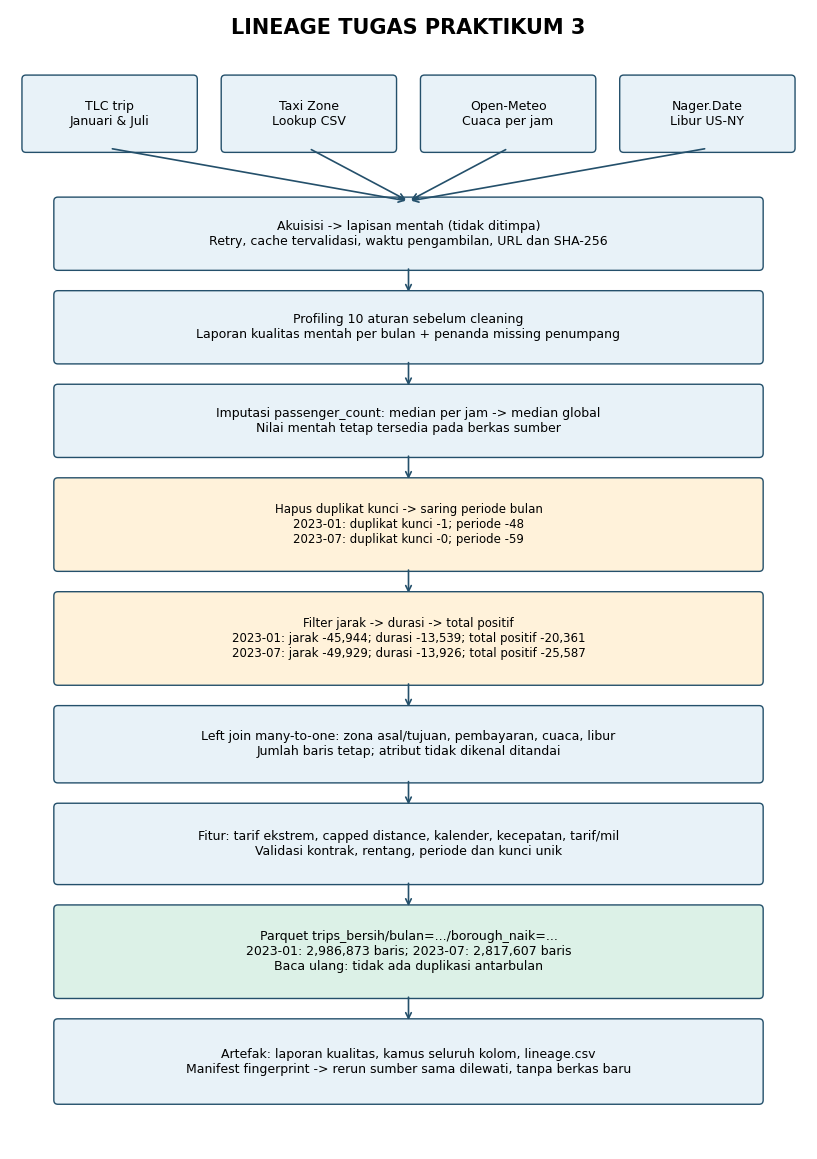

In [ ]:
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(8.27, 11.69))
ax.set_xlim(0, 10); ax.set_ylim(0, 14); ax.axis("off")
def box(x, y, w, h, teks, warna="#e8f2f8", ukuran=9):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05", facecolor=warna, edgecolor="#24506b"))
    ax.text(x+w/2, y+h/2, teks, ha="center", va="center", fontsize=ukuran)
def arrow(x1,y1,x2,y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1), arrowprops=dict(arrowstyle="->", color="#24506b", lw=1.2))
ax.text(5, 13.7, "LINEAGE TUGAS PRAKTIKUM 3", ha="center", fontsize=15, weight="bold")
for x,t in [(0.2,"TLC trip\nJanuari & Juli"),(2.7,"Taxi Zone\nLookup CSV"),(5.2,"Open-Meteo\nCuaca per jam"),(7.7,"Nager.Date\nLibur US-NY")]:
    box(x,12.3,2.1,0.85,t);arrow(x+1.05,12.3,5,11.65)
box(0.6,10.85,8.8,0.8,"Akuisisi -> lapisan mentah (tidak ditimpa)\nRetry, cache tervalidasi, waktu pengambilan, URL dan SHA-256")
arrow(5,10.85,5,10.5)
box(0.6,9.7,8.8,0.8,"Profiling 10 aturan sebelum cleaning\nLaporan kualitas mentah per bulan + penanda missing penumpang")
arrow(5,9.7,5,9.35)
box(0.6,8.55,8.8,0.8,"Imputasi passenger_count: median per jam -> median global\nNilai mentah tetap tersedia pada berkas sumber")
arrow(5,8.55,5,8.2)
labels=[]
for r in ringkasan_bulan:
    labels.append(r["bulan"]+": "+"; ".join(f"{t['tahap']} -{t['dibuang']:,}" for t in r["tahap"][1:3]))
box(0.6,7.15,8.8,1.05,"Hapus duplikat kunci -> saring periode bulan\n"+"\n".join(labels),"#fff2da",8.5)
arrow(5,7.15,5,6.8)
labels=[]
for r in ringkasan_bulan:
    labels.append(r["bulan"]+": "+"; ".join(f"{t['tahap']} -{t['dibuang']:,}" for t in r["tahap"][3:]))
box(0.6,5.75,8.8,1.05,"Filter jarak -> durasi -> total positif\n"+"\n".join(labels),"#fff2da",8.5)
arrow(5,5.75,5,5.4)
box(0.6,4.55,8.8,0.85,"Left join many-to-one: zona asal/tujuan, pembayaran, cuaca, libur\nJumlah baris tetap; atribut tidak dikenal ditandai")
arrow(5,4.55,5,4.2)
box(0.6,3.3,8.8,0.9,"Fitur: tarif ekstrem, capped distance, kalender, kecepatan, tarif/mil\nValidasi kontrak, rentang, periode dan kunci unik")
arrow(5,3.3,5,2.95)
box(0.6,1.9,8.8,1.05,"Parquet trips_bersih/bulan=.../borough_naik=...\n"+"; ".join(f"{r['bulan']}: {r['baris_bersih']:,} baris" for r in ringkasan_bulan)+"\nBaca ulang: tidak ada duplikasi antarbulan", "#dcf1e7")
arrow(5,1.9,5,1.55)
box(0.6,0.6,8.8,0.95,"Artefak: laporan kualitas, kamus seluruh kolom, lineage.csv\nManifest fingerprint -> rerun sumber sama dilewati, tanpa berkas baru")
fig.tight_layout()
fig.savefig(DIR_HASIL/"diagram_lineage.png", dpi=180, bbox_inches="tight")
plt.show()


## R-6. Reproducibility dan idempotensi

Seluruh kode dan referensi pembayaran didefinisikan di notebook ini. Tidak ada variabel yang harus diambil dari notebook P01/P02/P03. Jalankan Restart and run all di Colab untuk memverifikasi runtime Colab. Pengujian berikut menjalankan pipeline kedua kalinya dan membandingkan nama, ukuran, waktu modifikasi, serta SHA-256 semua berkas dataset. Sumber/parameter identik harus mempertahankan seluruh inventaris. Jika API atau file sumber berubah, hasil baru adalah versi sumber baru, bukan kegagalan idempotensi input yang sama.

Dataset ini siap untuk analisis deskriptif. Jika dipakai untuk model prediksi, median imputasi/cap/IQR yang dipelajari per bulan harus dipasang ulang hanya pada data latih agar tidak terjadi leakage. Cuaca satu koordinat tidak mewakili setiap borough; hari libur API tidak menjamin status buka/tutup bisnis; korelasi cuaca/libur dan tarif bukan sebab-akibat.


In [ ]:
def inventaris_dataset():
    return {str(p.relative_to(DATASET)): {"byte": p.stat().st_size, "mtime_ns": p.stat().st_mtime_ns,
            "sha256": sha256_file(p)} for p in DATASET.rglob("*") if p.is_file()}
inventaris_awal = inventaris_dataset()
ringkasan_ulang = [pipeline_tugas(b) for b in BULAN]
inventaris_akhir = inventaris_dataset()
assert inventaris_awal == inventaris_akhir, "Dataset berubah pada rerun input yang sama"
jumlah_ulang = ds.dataset(DATASET, format="parquet", partitioning="hive").count_rows()
assert jumlah_ulang == int(ringkasan["baris_bersih"].sum())
print("Idempoten untuk sumber dan parameter yang sama:", inventaris_awal == inventaris_akhir)
print("Berkas baru pada rerun:", len(set(inventaris_akhir)-set(inventaris_awal)))
print("Baris setelah rerun:", jumlah_ulang)
pemeriksaan = {"idempoten": True, "berkas_baru_rerun": 0, "jumlah_baris_tersimpan": jumlah_ulang,
    "duplikat_kunci": 0, "partisi_bulan": BULAN, "kolom_terdefinisi": len(kamus),
    "waktu_verifikasi": utc_sekarang(), "lingkungan": "Google Colab" if DI_COLAB else "lokal",
    "python": sys.version, "pustaka": {m: getattr(importlib.import_module(m), "__version__", "tersedia") for m in paket}}
(DIR_HASIL/"hasil_validasi.json").write_text(json.dumps(pemeriksaan, ensure_ascii=False, indent=2), encoding="utf-8")
shutil.make_archive(str(DIR_HASIL/"trips_bersih"), "zip", root_dir=DATASET)
print("Arsip trips_bersih.zip selesai dibuat")


Cache tervalidasi: yellow_tripdata_2023-01.parquet
Cache tervalidasi: taxi_zone_lookup.csv
Cache tervalidasi: cuaca_2023-01.json
Cache tervalidasi: hari_libur_US_2023.json
Partisi selesai dan sumber identik; dilewati: 2023-01
Cache tervalidasi: yellow_tripdata_2023-07.parquet
Cache tervalidasi: taxi_zone_lookup.csv
Cache tervalidasi: cuaca_2023-07.json
Cache tervalidasi: hari_libur_US_2023.json
Partisi selesai dan sumber identik; dilewati: 2023-07
Idempoten untuk sumber dan parameter yang sama: True
Berkas baru pada rerun: 0
Baris setelah rerun: 5804480
Arsip trips_bersih.zip selesai dibuat
